# Experiment 5: floor vs z-score vs prominence, against trusted boundaries

Notebooks 3 and 4 scored detectors against the floor's own cuts, but the floor is exactly the mechanism under suspicion, so that reference is circular. Here we build **trusted boundaries** and score against those.

**What counts as an error, given the two-stage design.** The pipeline tolerates over-segmentation: one article split into several small units is fine, because the Louvain stage regroups them into one community. So an *extra* cut inside an article is free. The only real harm is a **missed** boundary: then a single unit straddles two topics, a blend the community stage cannot undo because the contamination is *inside* the unit. Therefore:

- The quality metric is **boundary recall**. Harm = `1 - recall` (the fraction of real boundaries that became straddling units).
- Precision against these boundaries is **not** computed: an extra within-article cut is not a false positive, it is the design working as intended.
- This asymmetry (over-cut cheap, under-cut permanent) means an **aggressive** detector is the safe choice and a **strict** one is dangerous, which already predicts that the floor's aggressiveness helps and the z-score's strictness hurts.

**Trusted boundaries.** Two sets: the synthetic library passage from notebook 1, where the facet structure is known by construction (complete ground truth), and the KPC statute, where a new article (`Art. N.` at the start of a segment) is an objective, reproducible topic boundary. Articles are coarser than units, but that is fine: they are boundaries the detector *must* catch, not the only cuts it is allowed.

**Fair comparison.** We compare methods by their *ranking*, not their shipped threshold, so we separate "the signal is good" from "the threshold is miscalibrated". The headline is **recall at a matched cut budget** (let each method make exactly as many cuts as there are true boundaries, top-scored first) and the full **recall vs cut-count** curve. Shipped operating points are marked but are not the comparison.

In [1]:
from pathlib import Path
import re

import fitz
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.signal import find_peaks
from scipy.stats import median_abs_deviation

from text_change_detector.shared.embedder import SentenceTransformerEmbedder
from text_change_detector.tiling import pipeline
from text_change_detector.tiling.extraction.pdf import extract_pdf
from text_change_detector.tiling.extraction.shared import load_nlp

RADIUS = 15
WINDOW = 4
TOL = 1
FLOOR_D = 1.0 - 0.6
Z_SHIP = 3.0
C_FLOOR = '#c0392b'
C_Z = '#e08a1e'
C_PROM = '#2e86c1'
C_GT = '#555555'

/home/marek/repos/priv/text_change_detector/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def pick_device():
    if torch.cuda.is_available() and torch.cuda.mem_get_info()[0] > 9 * 1024 ** 3:
        return 'cuda'

    return 'cpu'


DEVICE = pick_device()
embedder = SentenceTransformerEmbedder(device=DEVICE, batch_size=8)

print('device:', DEVICE)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:  25%|██▍       | 99/398 [00:00<00:00, 984.86it/s]

Loading weights:  50%|████▉     | 198/398 [00:00<00:00, 939.18it/s]

Loading weights:  74%|███████▎  | 293/398 [00:00<00:00, 916.15it/s]

Loading weights:  97%|█████████▋| 388/398 [00:00<00:00, 918.26it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 939.61it/s]

device: cuda


## Trusted boundaries 1: the synthetic passage (complete ground truth)

The 40-sentence library passage, with the facet boundaries marked by hand. Each gap in `SYN_GT` is a place where the subject changes (registration -> limits, renewals -> reservations, and so on). The print marks them so the annotation can be audited. Facet edges are a little fuzzy, so matching later uses a +/-1 gap tolerance.

In [3]:
SYN = [
    'The city library lends books to any resident who holds a valid membership card.',
    'A new member registers at the front desk by presenting a photo ID and proof of address.',
    'The librarian then issues a card that is valid for three years from the date of registration.',
    'Each member may borrow up to ten books at a time.',
    'The standard loan period for a book is twenty-one days.',
    'A member can check the due date printed on the receipt handed out at the counter.',
    'Borrowed books may be renewed twice if no other reader has reserved them.',
    'A renewal extends the loan by a further twenty-one days from the day it is granted.',
    "Members renew a book either at the desk or through the library's online catalogue.",
    'When a title is already on loan, a member may place a reservation on it.',
    'The system notifies the member by email as soon as a reserved book is returned.',
    'A reserved book is then held at the pickup shelf for seven days.',
    'If the member does not collect it within that week, the reservation is cancelled.',
    "Returning a book on time keeps the member's account in good standing.",
    'A book returned after its due date incurs a fine of twenty cents per day.',
    'The fine stops accruing once the outstanding balance reaches ten euros for a single title.',
    'Members can pay their fines at the desk or online through the member portal.',
    'An account with unpaid fines above five euros is blocked from further borrowing.',
    'The block is lifted automatically the moment the balance falls back below that limit.',
    'Books may be returned to the front desk during opening hours.',
    'Outside opening hours, members drop books into the return bin beside the main entrance.',
    'Staff empty the return bin every morning and check each book back into the system.',
    'A book is only counted as returned once staff have scanned it at the desk.',
    'Damaged books are set aside for the repair team to assess.',
    'A member who returns a badly damaged book may be charged its replacement cost.',
    'Lost books are billed at the replacement cost plus a small processing fee.',
    'Reference books and rare editions are marked as non-circulating and cannot be borrowed.',
    'These titles may only be consulted inside the reading room.',
    "Children under twelve borrow on a junior card linked to a parent's account.",
    'The junior card carries a lower borrowing limit of five books at a time.',
    'Audiobooks and DVDs follow the same loan period as printed books.',
    'However, DVDs may not be renewed and must be returned within the first loan period.',
    'Members can browse the full catalogue from home using their card number and a PIN.',
    'The online catalogue shows whether each copy is available, on loan, or reserved.',
    'A member who forgets their PIN can reset it by confirming their email address.',
    'The library sends a courtesy reminder three days before any book falls due.',
    'A second reminder follows on the morning after a book becomes overdue.',
    'Members who prefer paper notices can opt out of email reminders at the desk.',
    'All borrowing history is kept private and is visible only to the member and staff.',
    'Members may ask staff to erase their past borrowing records at any time.',
]
SYN_GT = [2, 5, 8, 12, 18, 22, 25, 27, 29, 31, 34, 37]

for i, s in enumerate(SYN):
    print(f'{i:2d}  {s[:78]}')

    if i in SYN_GT:
        print(f'    {"-" * 30} boundary (gap {i})')

print(f'\nsynthetic: {len(SYN)} sentences, {len(SYN_GT)} facet boundaries')

 0  The city library lends books to any resident who holds a valid membership card
 1  A new member registers at the front desk by presenting a photo ID and proof of
 2  The librarian then issues a card that is valid for three years from the date o
    ------------------------------ boundary (gap 2)
 3  Each member may borrow up to ten books at a time.
 4  The standard loan period for a book is twenty-one days.
 5  A member can check the due date printed on the receipt handed out at the count
    ------------------------------ boundary (gap 5)
 6  Borrowed books may be renewed twice if no other reader has reserved them.
 7  A renewal extends the loan by a further twenty-one days from the day it is gra
 8  Members renew a book either at the desk or through the library's online catalo
    ------------------------------ boundary (gap 8)
 9  When a title is already on loan, a member may place a reservation on it.
10  The system notifies the member by email as soon as a reserved book is ret

## Trusted boundaries 2: KPC article structure (objective)

In the statute, a segment that begins with `Art. N.` starts a new article: a self-contained provision, hence a genuine topic boundary. We take those as ground truth over the code body (from the first article onward; the front-matter announcement has no articles and is excluded). This is objective and reproducible, no hand judgement. Articles are coarser than the units the tiler makes, which is exactly the point: they are the boundaries a unit must never straddle.

In [4]:
PDF = next(p for p in [Path('data/DU_2023_1550_KPC.pdf'),
                       Path('experiments/data/DU_2023_1550_KPC.pdf')] if p.exists())
src = fitz.open(PDF)
fragment = fitz.open()
fragment.insert_pdf(src, from_page=0, to_page=49)
nlp = load_nlp('pl_core_news_sm')
kpc_segments = extract_pdf(fragment, nlp)
art = re.compile(r'^\s*Art\.\s*\d+')
art_idx = [i for i, s in enumerate(kpc_segments) if art.match(s.text)]
KPC_GT = sorted({i - 1 for i in art_idx if i > 0})
region_start = min(KPC_GT)
d_kpc = pipeline._step_dissimilarities([s.text for s in kpc_segments], embedder, WINDOW)
d_syn = pipeline._step_dissimilarities(SYN, embedder, WINDOW)

embedder.close()

print(f'KPC gaps            : {len(d_kpc)}')
print(f'article boundaries  : {len(KPC_GT)}  (first at gap {region_start})')
print(f'code-body region    : gaps {region_start}..{len(d_kpc) - 1}  ({len(d_kpc) - region_start} gaps)')
print(f'boundary density in region: {len(KPC_GT) / (len(d_kpc) - region_start):.1%}')

KPC gaps            : 1000
article boundaries  : 26  (first at gap 158)
code-body region    : gaps 158..999  (842 gaps)
boundary density in region: 3.1%


## The three detectors and the metric

Each detector turns `d` into a per-gap score; higher means "more likely a boundary".

- **floor**: the score is `d` itself (the floor cuts where `d` is absolutely high).
- **local z-score**: `(d[k] - local median) / local MAD` over radius 15, the current `_is_boundary` signal.
- **prominence**: peak prominence of `d` (`scipy.signal.find_peaks`), the modern depth score; a local shape feature, zero for non-peaks.

`recall_at` counts how many ground-truth boundaries have a predicted cut within +/-1. `curve` sweeps the top-k highest-scored gaps and records recall against cut count, so methods are compared by ranking, not by their own threshold.

In [5]:
def local_z(d, radius=RADIUS):
    n = len(d)
    z = np.full(n, -np.inf)

    for k in range(n):
        lo = max(0, k - radius)
        hi = min(n, k + radius + 1)
        local = d[lo:hi]
        s = median_abs_deviation(local, scale='normal')

        if s > 0:
            z[k] = (d[k] - np.median(local)) / s

    return z


def prominence(d):
    prom = np.zeros(len(d))
    peaks, props = find_peaks(d, prominence=0)
    prom[peaks] = props['prominences']

    return prom


def scores(d):
    return {'floor': d, 'z-score': local_z(d), 'prominence': prominence(d)}


def recall_at(pred, gt, tol=TOL):
    pred = set(pred)
    hit = sum(any(abs(g - p) <= tol for p in pred) for g in gt)

    return hit / len(gt)


def curve(score, gt, region, tol=TOL):
    cand = sorted(region, key=lambda g: score[g], reverse=True)
    ks, recalls = [], []
    hit = set()

    for k, g in enumerate(cand, start=1):
        for t in gt:
            if t not in hit and abs(t - g) <= tol:
                hit.add(t)

        ks.append(k)
        recalls.append(len(hit) / len(gt))

    return np.array(ks), np.array(recalls)


def shipped_cut(name, score, region):
    if name == 'floor':
        pred = [g for g in region if score[g] >= FLOOR_D]
    elif name == 'z-score':
        pred = [g for g in region if score[g] >= Z_SHIP]
    else:
        peaks = score[[g for g in region if score[g] > 0]]
        cutoff = peaks.mean() - 0.5 * peaks.std() if len(peaks) else 0.0
        pred = [g for g in region if score[g] > 0 and score[g] >= cutoff]

    return pred

## Recall against the trusted boundaries

Left: the synthetic passage. Right: the KPC code body. Each curve is recall vs how many gaps the method cuts (top-scored first). The dashed grey line is the matched budget (cut exactly as many gaps as there are true boundaries). Dots mark each method's shipped operating point. A curve that reaches high recall while far to the left finds real boundaries with few cuts; because over-cutting is cheap here, the ranking near the matched budget is what matters.

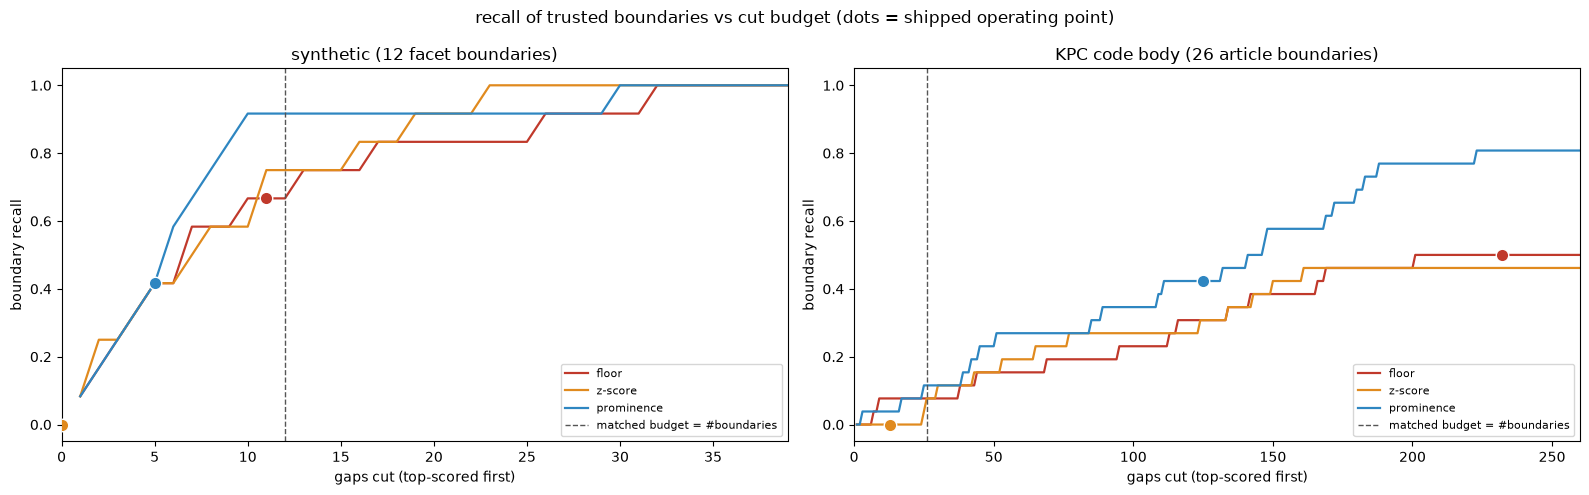

In [6]:
syn_scores = scores(d_syn)
kpc_scores = scores(d_kpc)
syn_region = list(range(len(d_syn)))
kpc_region = list(range(region_start, len(d_kpc)))
colors = {'floor': C_FLOOR, 'z-score': C_Z, 'prominence': C_PROM}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sc, gt, region, title, xmax in [
    (axes[0], syn_scores, SYN_GT, syn_region, 'synthetic (12 facet boundaries)', len(d_syn)),
    (axes[1], kpc_scores, KPC_GT, kpc_region, 'KPC code body (26 article boundaries)', 260),
]:
    for name in ['floor', 'z-score', 'prominence']:
        ks, rec = curve(sc[name], gt, region)

        ax.plot(ks, rec, color=colors[name], label=name, linewidth=1.6)

        pred = shipped_cut(name, sc[name], region)

        ax.plot(len(pred), recall_at(pred, gt), 'o', color=colors[name], markersize=9,
                markeredgecolor='white', zorder=5)

    ax.axvline(len(gt), color=C_GT, linestyle='--', linewidth=1, label='matched budget = #boundaries')
    ax.set_xlim(0, xmax)
    ax.set_xlabel('gaps cut (top-scored first)')
    ax.set_ylabel('boundary recall')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('recall of trusted boundaries vs cut budget (dots = shipped operating point)')
plt.tight_layout()
plt.show()

## The two headline numbers

**Matched-budget recall**: give each method exactly `#boundaries` cuts (its top-scored gaps) and see how many real boundaries it lands on. This is threshold-free, so it measures the signal's ranking alone. **Shipped-op recall**: what the method actually recovers at its default threshold, and how many cuts that takes. The gap between the two is how much is lost to threshold miscalibration.

In [7]:
def matched_recall(score, gt, region):
    top = sorted(region, key=lambda g: score[g], reverse=True)[:len(gt)]
    return recall_at(top, gt)


rows = []

for name in ['floor', 'z-score', 'prominence']:
    syn_mb = matched_recall(syn_scores[name], SYN_GT, syn_region)
    kpc_mb = matched_recall(kpc_scores[name], KPC_GT, kpc_region)
    syn_pred = shipped_cut(name, syn_scores[name], syn_region)
    kpc_pred = shipped_cut(name, kpc_scores[name], kpc_region)

    rows.append((name, syn_mb, kpc_mb,
                 recall_at(syn_pred, SYN_GT), len(syn_pred),
                 recall_at(kpc_pred, KPC_GT), len(kpc_pred)))

hdr = (f'{"method":12s} | {"matched-budget recall":21s} | {"shipped-op recall (cuts)":s}')

print(hdr)
print(f'{"":12s} | {"syn":>9s} {"KPC":>9s}   | {"syn":>13s}   {"KPC":>15s}')
print('-' * 78)

for name, smb, kmb, ssr, ssc, ksr, ksc in rows:
    print(f'{name:12s} | {smb:9.0%} {kmb:9.0%}   | {ssr:6.0%} ({ssc:3d})   {ksr:6.0%} ({ksc:4d})')

print(f'\nreference: {len(SYN_GT)} synthetic boundaries, {len(KPC_GT)} KPC article boundaries')
print(f'KPC code-body region: {len(kpc_region)} gaps')

method       | matched-budget recall | shipped-op recall (cuts)
             |       syn       KPC   |           syn               KPC
------------------------------------------------------------------------------
floor        |       67%        8%   |    67% ( 11)      50% ( 232)
z-score      |       75%        8%   |     0% (  0)       0% (  13)
prominence   |       92%       12%   |    42% (  5)      42% ( 125)

reference: 12 synthetic boundaries, 26 KPC article boundaries
KPC code-body region: 842 gaps


## Observations

**Two findings, on different axes. (1) On clean text the *shape* signal (prominence) ranks true boundaries best, which vindicates the direction. (2) On real legal text no dissimilarity threshold recovers article structure well, because article boundaries are not semantic jumps. The second is a deeper limit than floor-vs-z-score.**

**Clean text, ranking quality (matched budget, threshold-free).** Give each method exactly 12 cuts, top scored first: **prominence 92%, z-score 75%, floor 67%.** So the shape feature ranks the facet boundaries best, and the absolute-level floor ranks them *worst*, even here. The floor's apparent adequacy in notebook 3 was the luck of its absolute scale landing 11 cuts near the right places, not signal quality: as a ranker it is the weakest of the three.

**Clean text, shipped thresholds.** floor 67% at 11 cuts, **z-score 0% at 0 cuts**, prominence 42% at 5 cuts. The z-score's signal is fine (75% by ranking) but its `3.0` threshold cuts nothing; the failure is purely calibration. Prominence's signal is best but Hearst's `mean - 0.5*std` cutoff is too conservative here. So every shipped threshold is miscalibrated, each in its own direction, and comparing methods by ranking rather than by threshold was the right call.

**Real legal text, the humbling part.** Matched-budget recall (top-26 cuts over 842 gaps) is **floor 8%, z-score 8%, prominence 12%.** The most-dissimilar / most-prominent gaps in the statute are almost never at article starts. Even the aggressive floor at its shipped setting (**232 cuts, 28% of the region**) recovers only **50%** of the 26 article boundaries: half the articles are straddled by a unit. The dissimilarity signal barely tracks article structure, because consecutive articles share the same legal register and an article transition is not an embedding discontinuity. The bottleneck here is the *signal's power on this domain*, not the statistic or the threshold.

**The asymmetry is confirmed.** On real text the floor's 50% comes purely from cutting a lot and hitting half by density, the safe hedge when the signal is weak; the strict z-score gives 0%, catastrophic (every article straddled). In this two-stage architecture, aggressive beats strict exactly as predicted, and that, not any cleverness, is why the floor is serviceable in production.

**Caveats.** Article boundaries may over-count: two consecutive articles on the same subject are not a topic shift, so a unit spanning them is harmless, and the true topic-boundary recall is somewhat higher than these numbers. Matching uses +/-1 tolerance. So the absolute recalls are conservative, but the *relative* ordering (prominence > z-score > floor on clean text; all weak on legal text) is robust.

**So what.**
- If segmentation stays embedding-based, **prominence is the better signal** and is the candidate to keep. Its remaining unproven claim is embedder-invariance, which the next notebook must test by re-running the ranking on a second, differently-scaled embedder. And every method needs a threshold *derived from the signal*, not shipped as a constant: the matched-budget vs shipped-op gap shows all three defaults are off.
- For statutes specifically, the larger lever is **structural, not statistical**. The `Art. N.` markers are already in the text; feeding them to the segmenter as boundary priors would beat any dissimilarity threshold, which tops out near 50% recall of exactly those boundaries. That is an extraction-stage change, orthogonal to floor / z-score / prominence.
- The floor's current real-world adequacy is aggressiveness under a weak signal, not intelligence. Fine as a safe hedge, but it should not be mistaken for the dissimilarity signal actually finding the structure.